## 2. Recreating IMSIP6 total BMB melting

This note book recreates the basal melting figure as submitted in the official paper (credit to Helene Seroussi). Additionally we load a table and group the result by average melting in 2100, 2200 and 2300 and and melt parameterization.

In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n

import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
sns.set_context("paper")
sns.set_style("whitegrid")
computed_name = 'ComputedScalars'

pth_volume = '/Volumes/CrucialX8/computing/data/antarctica/ismip6_hackathon/'

In [2]:
df = pd.read_csv('metadata.txt')
df['melt2100'] = 0
df['melt2200'] = 0
df['melt2300'] = 0
df

,Unnamed: 0,Climate Forcing,Experiment,GL melt,GL treatment,Group,Main submission,Melt parameterisation,Melt parameters,Model,Model setup,Resolution,Resolution GL,fileID,melt2100,melt2200,melt2300
0,0,ctrl,ctrlAE,Sub-Grid,Sub-Grid,DC,1.0,Quad. Non-local,AntMean median,ISSM,DC\_ISSM,4km,4km,DC_ISSM,0,0,0
1,1,CCSM4,expAE02,Sub-Grid,Sub-Grid,DC,1.0,Quad. Non-local,AntMean median,ISSM,DC\_ISSM,4km,4km,DC_ISSM,0,0,0
2,2,HadGEM2,expAE03,Sub-Grid,Sub-Grid,DC,1.0,Quad. Non-local,AntMean median,ISSM,DC\_ISSM,4km,4km,DC_ISSM,0,0,0
3,3,CESM2,expAE04,Sub-Grid,Sub-Grid,DC,1.0,Quad. Non-local,AntMean median,ISSM,DC\_ISSM,4km,4km,DC_ISSM,0,0,0
4,4,UKESM,expAE05,Sub-Grid,Sub-Grid,DC,1.0,Quad. Non-local,AntMean median,ISSM,DC\_ISSM,4km,4km,DC_ISSM,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,210,ctrl,ctrlAE,Sub-Grid,Yes,VUW,0.0,Lin,custom,PISM,VUW\_PISM2\_s4,8km,4km,VUW_PISM2_s4,0,0,0
211,211,CCSM4,expAE02,Sub-Grid,Yes,VUW,0.0,Lin,custom,PISM,VUW\_PISM2\_s4,8km,4km,VUW_PISM2_s4,0,0,0
212,212,HadGEM2,expAE03,Sub-Grid,Yes,VUW,0.0,Lin,custom,PISM,VUW\_PISM2\_s4,8km,4km,VUW_PISM2_s4,0,0,0
213,213,CESM2,expAE04,Sub-Grid,Yes,VUW,0.0,Lin,custom,PISM,VUW\_PISM2\_s4,8km,4km,VUW_PISM2_s4,0,0,0


In [3]:
variable2 = 'dslc_anom'
mnt_pth = '/Volumes/CrucialX8/computing/data/antarctica/' #mount path

pth_imip6hack= mnt_pth + 'ismip6_hackathon/ComputedScalars/'

In [5]:
import matplotlib.ticker as ticker

/Volumes/CrucialX8/computing/data/antarctica/ismip6_hackathon/ComputedScalars//expAE02/thermalforcing/computed_thermalforcing_AIS_DOE_MALI_3_expAE02.nc
/Volumes/CrucialX8/computing/data/antarctica/ismip6_hackathon/ComputedScalars//expAE03/thermalforcing/computed_thermalforcing_AIS_DOE_MALI_3_expAE03.nc
/Volumes/CrucialX8/computing/data/antarctica/ismip6_hackathon/ComputedScalars//expAE04/thermalforcing/computed_thermalforcing_AIS_DOE_MALI_3_expAE04.nc
/Volumes/CrucialX8/computing/data/antarctica/ismip6_hackathon/ComputedScalars//expAE05/thermalforcing/computed_thermalforcing_AIS_DOE_MALI_3_expAE05.nc


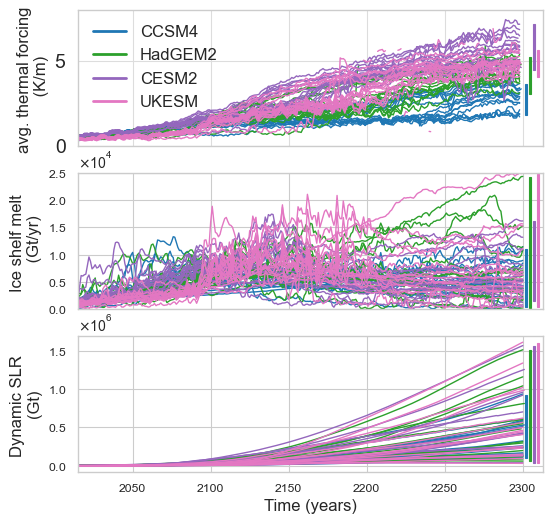

In [8]:
time = np.arange(2016, 2301)
i_2100= np.argwhere(time == 2091)[0][0]
i_2200= np.argwhere(time == 2191)[0][0]
i_2300= np.argwhere(time == 2291)[0][0]

renamer = {}
renamer['DOE_MALI_4km']='DOE_MALI_1'
renamer['DOE_MALI_8km_Ant95']='DOE_MALI_2'
renamer['DOE_MALI_8km_AntMean']='DOE_MALI_3'  

variable3 = 'thermalforcing'

expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
expnames_plot = ['CCSM4','HadGEM2','CESM2','UKESM']

# Create a dictionary to store the lists
valuesend_dict = {expname: [] for expname in expnames}
valuesend_dict2 = {expname: [] for expname in expnames}
valuesend_dict3 = {expname: [] for expname in expnames}


dic_all = {}

# colors = np.array([[0, 0.4470, 0.7410], [0.8500, 0.3250, 0.0980], [0.9290, 0.6940, 0.1250], [0.4660, 0.6740, 0.1880]])
colors = ['#1f77b4',
    '#2ca02c',
    '#9467bd',
    '#e377c2']
f,ax2 = plt.subplots(3,1, figsize = (6,6),sharex =True)

# Go over computed scalars and cleanup file names
for iexp, expname in enumerate(expnames):
    dic_climateforcing = {}
    file_exp = os.listdir(f"{computed_name}/{expname}/shelfmelt")
    file_exp = [file for file in file_exp if len(file) >= 3]
    
    for ifile in reversed(range(len(file_exp))):
        if len(file_exp[ifile]) < 3:
            del file_exp[ifile]

    for ifile in range(len(file_exp)):
        filename = f"{computed_name}/{expname}/shelfmelt/{file_exp[ifile]}"
        
        dataname = file_exp[ifile]
        n1,n2 = dataname.split('shelfmelt')
        dataname =n1 +variable2 +n2
        dataname3 =n1 +variable3 +n2
        
        filename2 =f'{pth_imip6hack}/{expname}/{variable2}/{dataname}'
        filename3 =f'{pth_imip6hack}/{expname}/{variable3}/{dataname3}'
        malis ='DOE_MALI_4km'
        if malis in file_exp[ifile]:
            filename3 =filename3.replace(malis ,renamer[malis] )
        malis = 'DOE_MALI_8km_Ant95'
        if malis in file_exp[ifile]:
            filename3=filename3.replace(malis ,renamer[malis] )
        malis = 'DOE_MALI_8km_AntMean'
        if malis in file_exp[ifile]:
            filename3 =filename3.replace(malis ,renamer[malis] )
            print(filename3)
#         if 'DOE_MALI_4km' in file_exp[ifile];
#             filename3.replace('DOE_MALI_4km' ,renamer['DOE_MALI_4km'] )
#             'DOE_MALI_8km_Ant95'
            
#         filename3 =f'{pth_imip6hack}/{expname}/{variable3}/{dataname3}'
        

        if "IMAU" in file_exp[ifile]:
#             print(file_exp[ifile])
            file_exp[ifile].replace('computed_shelfmelt_AIS','jb_computed_shelfmelt_AIS')
        filename = f"{computed_name}/{expname}/shelfmelt/{file_exp[ifile]}"
        
        
            
        d = xr.open_dataset(filename,decode_times=False )
        data = d.shelfmelt.values * 365.25 * 24 * 3600 / 10**12
        
       
        d2 = xr.open_dataset(filename2,decode_times=False ) #already GT/yr
        
        data2 = d2.dslc_anom.values
        
        d3 = xr.open_dataset(filename3,decode_times=False ) #K
        
        data3 = d3.thermalforcing.values
        
        
        
        
#         time = d.time
      

     

        if ("NORCE" in file_exp[ifile] and "NORCE_CISM3-MAR364-ERA-t1-non" not in file_exp[ifile]) or \
           ("VUW" in file_exp[ifile] and "VUW_PISM1_e" not in file_exp[ifile]) or \
           ("DOE" in file_exp[ifile] and "DOE_MALI_4km" not in file_exp[ifile]) or \
           ("NCAR" in file_exp[ifile] and "NCAR_CISM2" not in file_exp[ifile]) or \
           ("LSCE" in file_exp[ifile] and "LSCE_GRISLI_e" not in file_exp[ifile]) or \
           ("ULB" in file_exp[ifile] and "ULB_fETISh-KoriBU1" not in file_exp[ifile]) or \
           ("IMAU" in file_exp[ifile] and "IMAU_UFEMISM1" not in file_exp[ifile]):
            pass
        else:
            modelrun = file_exp[ifile].split('AIS_')[-1].split(expname)[0]
            modelrun = modelrun[:-1]
            if len(data) > 250:

                if data[-1] > 0:
                    data = -data

                if -np.sum(data[:285]) > 4 * 10**6 or -np.sum(data[:285]) < 0:
                    print(filename)
                else:
                    valuesend_dict[expname].append(-data[time.size-1])
                    ax = ax2[1]
                    ax.plot(d.time, -(data[:d.time.size]), linewidth=1, color=colors[iexp])
                    
                    
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2100'] = -data[i_2100:i_2100+10].mean()
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2200'] = -data[i_2200:i_2200+10].mean()
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2300'] = -data[i_2300:i_2300+10].mean()
        
                    
            else:
                print("experiment too short for")
                
            if len(data2) > 250:

                if data2[-1] > 0:
                    data2 = -data2

                if -np.sum(data[:285]) > 4 * 10**6 or -np.sum(data[:285]) < 0:
                    print(filename)
                else:
                    valuesend_dict2[expname].append(-data2[time.size-1])
                    ax = ax2[2]
                    ax.plot(d2.time, -(data2[:d2.time.size]), linewidth=1, color=colors[iexp])
                    
                    
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2100'] = -data[i_2100:i_2100+10].mean()
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2200'] = -data[i_2200:i_2200+10].mean()
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2300'] = -data[i_2300:i_2300+10].mean()
        
                    
            else:
                print("experiment too short for")
            if len(data3) > 250:

                valuesend_dict3[expname].append(data3[time.size-3])
                ax = ax2[0]
                ax.plot(d2.time.values[:d3.time.size-2], data3[:d3.time.size-2], linewidth=1, color=colors[iexp])
                    
            else:
                print("experiment too short for")
                
                
                
                
        dic_all[expname]=dic_climateforcing
        


for iexp, expname in enumerate(expnames):
    x = [2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp, 2303 + 2.5 * iexp]
    y = [np.min(valuesend_dict[expname]), np.max(valuesend_dict[expname]),
         np.max(valuesend_dict[expname]), np.min(valuesend_dict[expname])]
    ax2[1].fill(x, y, [-1, -1, -1, -1], color=colors[iexp], edgecolor=colors[iexp])
    
for iexp, expname in enumerate(expnames):
    x = [2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp, 2303 + 2.5 * iexp]
    y = [np.min(valuesend_dict2[expname]), np.max(valuesend_dict2[expname]),
         np.max(valuesend_dict2[expname]), np.min(valuesend_dict2[expname])]
    ax2[2].fill(x, y, [-1, -1, -1, -1], color=colors[iexp], edgecolor=colors[iexp])
    
for iexp, expname in enumerate(expnames):
    x = [2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp, 2303 + 2.5 * iexp]
    y = [np.nanmin(valuesend_dict3[expname]), np.nanmax(valuesend_dict3[expname]),
         np.nanmax(valuesend_dict3[expname]), np.nanmin(valuesend_dict3[expname])]
    ax2[0].fill(x, y, [-1, -1, -1, -1], color=colors[iexp], edgecolor=colors[iexp])

ax2[0].set_ylim([0,8])
ax2[1].set_ylim([0, 2.5 * 10**4])
ax2[2].set_xlabel('Time (years)', fontsize=12)
ax2[1].set_ylabel('Ice shelf melt \n (Gt/yr)', fontsize=12)
# ax = ax2[1]

ax2[2].set_ylabel('Dynamic SLR \n(Gt)', fontsize=12)


ax2[0].set_ylabel('avg. thermal forcing \n (K/m)', fontsize=12)



legend_lines = [mlines.Line2D([], [], color=colors[i], linewidth=2, label=expname) for i, expname in enumerate(expnames_plot)]
ax2[0].legend(handles=legend_lines, loc='upper left', fontsize=12, frameon = False)

# plt.legend(expnames, loc='upper left', fontsize=14)
# plt.text(1985, 0, 'b', verticalalignment='middle', horizontalalignment='right', fontsize=18, fontweight='b')
ax2[1].set_xlim([2015, 2313])
ax2[2].set_xlim([2015, 2313])

# plt.gca().set_position([0.1300, 0.1100, 0.7750, 0.3812])
ax.tick_params(labelsize=14)
ax.grid(which='major', color='#DDDDDD', linewidth=0.8)
ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.5)

for i in range(3):
    ax = ax2[i]
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis="y", style="scientific", scilimits=(0, 0))  # Always show scientific notation
    ax.yaxis.offsetText.set_fontsize(10)
# plt.savefig('Figures/SMB_BMB_2300forcing_onemember.pdf', format='pdf', bbox_inches='tight')
plt.show()
# f.tight_layout()
f.savefig('analysis/figs/paper/Intropic.jpeg')
f.savefig('analysis/figs/paper/Intropic.pdf')

/Volumes/CrucialX8/computing/data/antarctica/ismip6_hackathon/ComputedScalars//expAE02/thermalforcing/computed_thermalforcing_AIS_DOE_MALI_3_expAE02.nc
/Volumes/CrucialX8/computing/data/antarctica/ismip6_hackathon/ComputedScalars//expAE03/thermalforcing/computed_thermalforcing_AIS_DOE_MALI_3_expAE03.nc
/Volumes/CrucialX8/computing/data/antarctica/ismip6_hackathon/ComputedScalars//expAE04/thermalforcing/computed_thermalforcing_AIS_DOE_MALI_3_expAE04.nc
/Volumes/CrucialX8/computing/data/antarctica/ismip6_hackathon/ComputedScalars//expAE05/thermalforcing/computed_thermalforcing_AIS_DOE_MALI_3_expAE05.nc


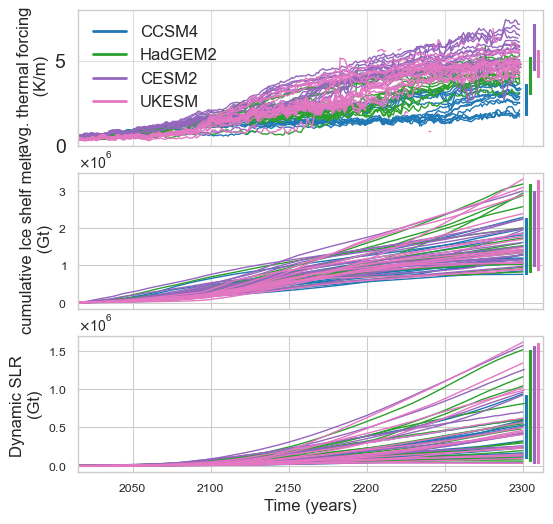

In [13]:
time = np.arange(2016, 2301)
i_2100= np.argwhere(time == 2091)[0][0]
i_2200= np.argwhere(time == 2191)[0][0]
i_2300= np.argwhere(time == 2291)[0][0]

renamer = {}
renamer['DOE_MALI_4km']='DOE_MALI_1'
renamer['DOE_MALI_8km_Ant95']='DOE_MALI_2'
renamer['DOE_MALI_8km_AntMean']='DOE_MALI_3'  

variable3 = 'thermalforcing'

expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
expnames_plot = ['CCSM4','HadGEM2','CESM2','UKESM']

# Create a dictionary to store the lists
valuesend_dict = {expname: [] for expname in expnames}
valuesend_dict2 = {expname: [] for expname in expnames}
valuesend_dict3 = {expname: [] for expname in expnames}


dic_all = {}

# colors = np.array([[0, 0.4470, 0.7410], [0.8500, 0.3250, 0.0980], [0.9290, 0.6940, 0.1250], [0.4660, 0.6740, 0.1880]])
colors = ['#1f77b4',
    '#2ca02c',
    '#9467bd',
    '#e377c2']
f,ax2 = plt.subplots(3,1, figsize = (6,6),sharex =True)

# Go over computed scalars and cleanup file names
for iexp, expname in enumerate(expnames):
    dic_climateforcing = {}
    file_exp = os.listdir(f"{computed_name}/{expname}/shelfmelt")
    file_exp = [file for file in file_exp if len(file) >= 3]
    
    for ifile in reversed(range(len(file_exp))):
        if len(file_exp[ifile]) < 3:
            del file_exp[ifile]

    for ifile in range(len(file_exp)):
        filename = f"{computed_name}/{expname}/shelfmelt/{file_exp[ifile]}"
        
        dataname = file_exp[ifile]
        n1,n2 = dataname.split('shelfmelt')
        dataname =n1 +variable2 +n2
        dataname3 =n1 +variable3 +n2
        
        filename2 =f'{pth_imip6hack}/{expname}/{variable2}/{dataname}'
        filename3 =f'{pth_imip6hack}/{expname}/{variable3}/{dataname3}'
        malis ='DOE_MALI_4km'
        if malis in file_exp[ifile]:
            filename3 =filename3.replace(malis ,renamer[malis] )
        malis = 'DOE_MALI_8km_Ant95'
        if malis in file_exp[ifile]:
            filename3=filename3.replace(malis ,renamer[malis] )
        malis = 'DOE_MALI_8km_AntMean'
        if malis in file_exp[ifile]:
            filename3 =filename3.replace(malis ,renamer[malis] )
            print(filename3)
#         if 'DOE_MALI_4km' in file_exp[ifile];
#             filename3.replace('DOE_MALI_4km' ,renamer['DOE_MALI_4km'] )
#             'DOE_MALI_8km_Ant95'
            
#         filename3 =f'{pth_imip6hack}/{expname}/{variable3}/{dataname3}'
        

        if "IMAU" in file_exp[ifile]:
#             print(file_exp[ifile])
            file_exp[ifile].replace('computed_shelfmelt_AIS','jb_computed_shelfmelt_AIS')
        filename = f"{computed_name}/{expname}/shelfmelt/{file_exp[ifile]}"
        
        
            
        d = xr.open_dataset(filename,decode_times=False )
        data = d.shelfmelt.values * 365.25 * 24 * 3600 / 10**12
        
       
        d2 = xr.open_dataset(filename2,decode_times=False ) #already GT/yr
        
        data2 = d2.dslc_anom.values
        
        d3 = xr.open_dataset(filename3,decode_times=False ) #K
        
        data3 = d3.thermalforcing.values
        
        
        
        
#         time = d.time
      

     

        if ("NORCE" in file_exp[ifile] and "NORCE_CISM3-MAR364-ERA-t1-non" not in file_exp[ifile]) or \
           ("VUW" in file_exp[ifile] and "VUW_PISM1_e" not in file_exp[ifile]) or \
           ("DOE" in file_exp[ifile] and "DOE_MALI_4km" not in file_exp[ifile]) or \
           ("NCAR" in file_exp[ifile] and "NCAR_CISM2" not in file_exp[ifile]) or \
           ("LSCE" in file_exp[ifile] and "LSCE_GRISLI_e" not in file_exp[ifile]) or \
           ("ULB" in file_exp[ifile] and "ULB_fETISh-KoriBU1" not in file_exp[ifile]) or \
           ("IMAU" in file_exp[ifile] and "IMAU_UFEMISM1" not in file_exp[ifile]):
            pass
        else:
            modelrun = file_exp[ifile].split('AIS_')[-1].split(expname)[0]
            modelrun = modelrun[:-1]
            if len(data) > 250:

                if data[-1] > 0:
                    data = -data

                if -np.sum(data[:285]) > 4 * 10**6 or -np.sum(data[:285]) < 0:
                    print(filename)
                else:
                    valuesend_dict[expname].append(-data.cumsum()[time.size-1])
                    ax = ax2[1]
                    ax.plot(d.time, -(data[:d.time.size].cumsum()), linewidth=1, color=colors[iexp])
                    
                    
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2100'] = -data[i_2100:i_2100+10].mean()
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2200'] = -data[i_2200:i_2200+10].mean()
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2300'] = -data[i_2300:i_2300+10].mean()
        
                    
            else:
                print("experiment too short for")
                
            if len(data2) > 250:

                if data2[-1] > 0:
                    data2 = -data2

                if -np.sum(data[:285]) > 4 * 10**6 or -np.sum(data[:285]) < 0:
                    print(filename)
                else:
                    valuesend_dict2[expname].append(-data2[time.size-1])
                    ax = ax2[2]
                    ax.plot(d2.time, -(data2[:d2.time.size]), linewidth=1, color=colors[iexp])
                    
                    
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2100'] = -data[i_2100:i_2100+10].mean()
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2200'] = -data[i_2200:i_2200+10].mean()
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2300'] = -data[i_2300:i_2300+10].mean()
        
                    
            else:
                print("experiment too short for")
            if len(data3) > 250:

                valuesend_dict3[expname].append(data3[time.size-3])
                ax = ax2[0]
                ax.plot(d2.time.values[:d3.time.size-2], data3[:d3.time.size-2], linewidth=1, color=colors[iexp])
                    
            else:
                print("experiment too short for")
                
                
                
                
        dic_all[expname]=dic_climateforcing
        


for iexp, expname in enumerate(expnames):
    x = [2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp, 2303 + 2.5 * iexp]
    y = [np.min(valuesend_dict[expname]), np.max(valuesend_dict[expname]),
         np.max(valuesend_dict[expname]), np.min(valuesend_dict[expname])]
    ax2[1].fill(x, y, [-1, -1, -1, -1], color=colors[iexp], edgecolor=colors[iexp])
    
for iexp, expname in enumerate(expnames):
    x = [2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp, 2303 + 2.5 * iexp]
    y = [np.min(valuesend_dict2[expname]), np.max(valuesend_dict2[expname]),
         np.max(valuesend_dict2[expname]), np.min(valuesend_dict2[expname])]
    ax2[2].fill(x, y, [-1, -1, -1, -1], color=colors[iexp], edgecolor=colors[iexp])
    
for iexp, expname in enumerate(expnames):
    x = [2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp, 2303 + 2.5 * iexp]
    y = [np.nanmin(valuesend_dict3[expname]), np.nanmax(valuesend_dict3[expname]),
         np.nanmax(valuesend_dict3[expname]), np.nanmin(valuesend_dict3[expname])]
    ax2[0].fill(x, y, [-1, -1, -1, -1], color=colors[iexp], edgecolor=colors[iexp])

ax2[0].set_ylim([0,8])
# ax2[1].set_ylim([0, 2.5 * 10**4])
ax2[2].set_xlabel('Time (years)', fontsize=12)
ax2[1].set_ylabel('cumulative Ice shelf melt \n (Gt)', fontsize=12)
# ax = ax2[1]

ax2[2].set_ylabel('Dynamic SLR \n(Gt)', fontsize=12)


ax2[0].set_ylabel('avg. thermal forcing \n (K/m)', fontsize=12)



legend_lines = [mlines.Line2D([], [], color=colors[i], linewidth=2, label=expname) for i, expname in enumerate(expnames_plot)]
ax2[0].legend(handles=legend_lines, loc='upper left', fontsize=12, frameon = False)

# plt.legend(expnames, loc='upper left', fontsize=14)
# plt.text(1985, 0, 'b', verticalalignment='middle', horizontalalignment='right', fontsize=18, fontweight='b')
ax2[1].set_xlim([2015, 2313])
ax2[2].set_xlim([2015, 2313])

# plt.gca().set_position([0.1300, 0.1100, 0.7750, 0.3812])
ax.tick_params(labelsize=14)
ax.grid(which='major', color='#DDDDDD', linewidth=0.8)
ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.5)

for i in range(3):
    ax = ax2[i]
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis="y", style="scientific", scilimits=(0, 0))  # Always show scientific notation
    ax.yaxis.offsetText.set_fontsize(10)
# plt.savefig('Figures/SMB_BMB_2300forcing_onemember.pdf', format='pdf', bbox_inches='tight')
plt.show()
# f.tight_layout()
f.savefig('analysis/figs/SI/IntropiccumBMB.jpeg')
f.savefig('analysis/figs/SI/IntropiccumBMB.pdf')